In [2]:
import numpy as np
import torch
import torch.nn as nn
from torchdiffeq import odeint
from torchcfm.conditional_flow_matching import ConditionalFlowMatcher
from sklearn.preprocessing import StandardScaler
from scipy.stats import wasserstein_distance
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from TrajectoryNet import dataset
import pickle
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
eb_data = dataset.EBData("pcs", max_dim=50)
data = eb_data.data
labels = eb_data.get_times()

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)
timepoints = np.unique(labels)

def get_data_by_timepoint(data_scaled, labels):
    data_by_t = {}
    for t in np.unique(labels):
        mask = labels == t
        data_by_t[t] = torch.FloatTensor(data_scaled[mask]).to(device)
    return data_by_t

data_by_t = get_data_by_timepoint(data_scaled, labels)

obs_by_t_pca = {}
for t in timepoints:
    mask = labels == t
    obs_by_t_pca[t] = data[mask]

print(f"Data loaded: {data.shape}")

Data loaded: (16819, 50)


In [4]:
class ODEFunc(nn.Module):
    def __init__(self, dim, hidden_dim=64):
        super(ODEFunc, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 1, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, dim)
        )
    def forward(self, t, z):
        t_vec = t.expand(z.shape[0], 1)
        inp = torch.cat([z, t_vec], dim=1)
        return self.net(inp)

class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim, hidden_dim=128, dropout=0.1):
        super(VAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.BatchNorm1d(hidden_dim),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim), nn.BatchNorm1d(hidden_dim),
            nn.ReLU(), nn.Dropout(dropout)
        )
        self.fc_mu  = nn.Linear(hidden_dim, latent_dim)
        self.fc_var = nn.Linear(hidden_dim, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim), nn.BatchNorm1d(hidden_dim),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim), nn.BatchNorm1d(hidden_dim),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, input_dim)
        )
    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_var(h)
    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        return mu + std * torch.randn_like(std)
    def decode(self, z):
        return self.decoder(z)
    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        return self.decode(z), mu, log_var

class VectorField(nn.Module):
    def __init__(self, dim, hidden_dim=64):
        super(VectorField, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 1, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, dim)
        )
    def forward(self, t, x):
        if t.dim() == 0:
            t_vec = t.expand(x.shape[0], 1)
        else:
            t_vec = t.view(-1, 1).expand(x.shape[0], 1)
        return self.net(torch.cat([x, t_vec], dim=1))

print("All architectures defined.")

All architectures defined.


In [5]:
# Neural ODE on 50D PCA
model_node = ODEFunc(dim=50).to(device)
model_node.load_state_dict(torch.load('../models/node_50d.pt'))
model_node.eval()

# Sequential VAE + ODE
vae_seq = VAE(50, 10, 128, 0.1).to(device)
vae_seq.load_state_dict(torch.load('../models/vae.pt'))
vae_seq.eval()

model_vae_ode = ODEFunc(dim=6).to(device)
model_vae_ode.load_state_dict(torch.load('../models/node_vae.pt'))
model_vae_ode.eval()

with open('../models/scaler.pkl', 'rb') as f:
    scaler_vae = pickle.load(f)
active_dims = np.load('../data/active_dims.npy')
Z_latent = np.load('../data/Z_latent_active.npy')
labels_vae = np.load('../data/labels.npy')

def get_data_by_timepoint_raw(data, labels):
    data_by_t = {}
    for t in np.unique(labels):
        mask = labels == t
        data_by_t[t] = torch.FloatTensor(data[mask]).to(device)
    return data_by_t

data_by_t_vae = get_data_by_timepoint_raw(Z_latent, labels_vae)

# Joint VAE + ODE
joint_vae = VAE(50, 10, 128, 0.1).to(device)
joint_vae.load_state_dict(torch.load('../models/joint_vae.pt'))
joint_vae.eval()

joint_ode = ODEFunc(dim=10).to(device)
joint_ode.load_state_dict(torch.load('../models/joint_ode.pt'))
joint_ode.eval()

with open('../models/joint_scaler.pkl', 'rb') as f:
    scaler_joint = pickle.load(f)

# Flow Matching
model_fm = VectorField(dim=50).to(device)
model_fm.load_state_dict(torch.load('../models/flow_matching.pt'))
model_fm.eval()

print("All models loaded.")

All models loaded.


In [6]:
def evaluate_wasserstein(pred_by_t, obs_by_t_pca, timepoints, 
                          n_eval=500, n_runs=5):
    """
    Run Wasserstein evaluation n_runs times and return mean and std.
    pred_by_t: dict mapping timepoint -> numpy array of predicted cells in 50D PCA space
    """
    all_avgs = []
    for _ in range(n_runs):
        w_dists = []
        for t in timepoints[1:-1]:
            pred = pred_by_t[t]
            obs  = obs_by_t_pca[t]
            idx_obs = np.random.choice(len(obs), size=min(n_eval, len(pred)), replace=False)
            obs_s   = obs[idx_obs]
            pred_s  = pred[:len(obs_s)]
            w = np.mean([wasserstein_distance(pred_s[:, d], obs_s[:, d]) for d in range(50)])
            w_dists.append(w)
        all_avgs.append(np.mean(w_dists))
    return np.mean(all_avgs), np.std(all_avgs)

def get_node_predictions(model, data_by_t, timepoints, scaler_out, n_eval=500):
    """Get Neural ODE predictions in 50D PCA space."""
    t_span = torch.FloatTensor(timepoints).to(device)
    with torch.no_grad():
        idx = torch.randperm(data_by_t[0].shape[0])[:n_eval]
        z0  = data_by_t[0][idx]
        z_pred = odeint(model, z0, t_span, method='dopri5')
    pred_by_t = {}
    for i, t in enumerate(timepoints):
        pred_scaled = z_pred[i].cpu().numpy()
        pred_by_t[t] = scaler_out.inverse_transform(pred_scaled)
    return pred_by_t

def get_vae_ode_predictions(model_ode, data_by_t_vae, timepoints,
                             vae, scaler_vae, active_dims, n_eval=500):
    """Get sequential VAE+ODE predictions in 50D PCA space."""
    t_span = torch.FloatTensor(timepoints).to(device)
    with torch.no_grad():
        idx = torch.randperm(data_by_t_vae[0].shape[0])[:n_eval]
        z0  = data_by_t_vae[0][idx]
        z_pred = odeint(model_ode, z0, t_span, method='dopri5')
    pred_by_t = {}
    for i, t in enumerate(timepoints):
        z_pred_t = z_pred[i].cpu().numpy()
        z_full = np.zeros((z_pred_t.shape[0], 10))
        z_full[:, active_dims] = z_pred_t
        z_tensor = torch.FloatTensor(z_full).to(device)
        with torch.no_grad():
            recon = vae.decode(z_tensor).detach().cpu().numpy()
        pred_by_t[t] = scaler_vae.inverse_transform(recon)
    return pred_by_t

def get_joint_predictions(vae, ode, data_by_t, scaler_joint, timepoints, n_eval=500):
    """Get joint VAE+ODE predictions in 50D PCA space."""
    t_span = torch.FloatTensor(timepoints).to(device)
    with torch.no_grad():
        idx = torch.randperm(data_by_t[0].shape[0])[:n_eval]
        z0_input = data_by_t[0][idx]
        mu0, log_var0 = vae.encode(z0_input)
        z0 = vae.reparameterize(mu0, log_var0)
        z_pred = odeint(ode, z0, t_span, method='dopri5')
    pred_by_t = {}
    for i, t in enumerate(timepoints):
        x_pred = vae.decode(z_pred[i]).detach().cpu().numpy()
        pred_by_t[t] = scaler_joint.inverse_transform(x_pred)
    return pred_by_t

def get_fm_predictions(model, data_by_t, scaler, timepoints, n_eval=500):
    """Get Flow Matching predictions in 50D PCA space."""
    t_eval = torch.FloatTensor([0] + list(timepoints[1:])).to(device)
    with torch.no_grad():
        idx = torch.randperm(data_by_t[0].shape[0])[:n_eval]
        x0  = data_by_t[0][idx]
        def ode_fn(t, x): return model(t, x)
        z_pred = odeint(ode_fn, x0, t_eval, method='euler', options={'step_size': 0.1})
    pred_by_t = {}
    for i, t in enumerate(timepoints[1:]):
        pred_by_t[t] = scaler.inverse_transform(z_pred[i].cpu().numpy())
    return pred_by_t

print("Evaluation functions defined.")

Evaluation functions defined.


In [7]:
N_RUNS = 5
N_EVAL = 500

print("Running evaluations (5 runs each for robust estimates)...")
print("=" * 60)

# Neural ODE
preds_node = get_node_predictions(model_node, data_by_t, timepoints, scaler, N_EVAL)
avg_node, std_node = evaluate_wasserstein(preds_node, obs_by_t_pca, timepoints, N_EVAL, N_RUNS)
print(f"Neural ODE (50D PCA):        {avg_node:.4f} ± {std_node:.4f}")

# Sequential VAE + ODE
preds_vae_ode = get_vae_ode_predictions(model_vae_ode, data_by_t_vae, timepoints,
                                         vae_seq, scaler_vae, active_dims, N_EVAL)
avg_vae, std_vae = evaluate_wasserstein(preds_vae_ode, obs_by_t_pca, timepoints, N_EVAL, N_RUNS)
print(f"Sequential VAE + ODE:        {avg_vae:.4f} ± {std_vae:.4f}")

# Joint VAE + ODE
preds_joint = get_joint_predictions(joint_vae, joint_ode, data_by_t,
                                     scaler_joint, timepoints, N_EVAL)
avg_joint, std_joint = evaluate_wasserstein(preds_joint, obs_by_t_pca, timepoints, N_EVAL, N_RUNS)
print(f"Joint VAE + ODE:             {avg_joint:.4f} ± {std_joint:.4f}")

# Flow Matching
preds_fm = get_fm_predictions(model_fm, data_by_t, scaler, timepoints, N_EVAL)
avg_fm, std_fm = evaluate_wasserstein(preds_fm, obs_by_t_pca, timepoints, N_EVAL, N_RUNS)
print(f"Flow Matching (original):    {avg_fm:.4f} ± {std_fm:.4f}")

print("=" * 60)
print("Done.")

Running evaluations (5 runs each for robust estimates)...
Neural ODE (50D PCA):        0.2275 ± 0.0037
Sequential VAE + ODE:        0.7770 ± 0.0036
Joint VAE + ODE:             0.3854 ± 0.0044
Flow Matching (original):    0.3457 ± 0.0036
Done.


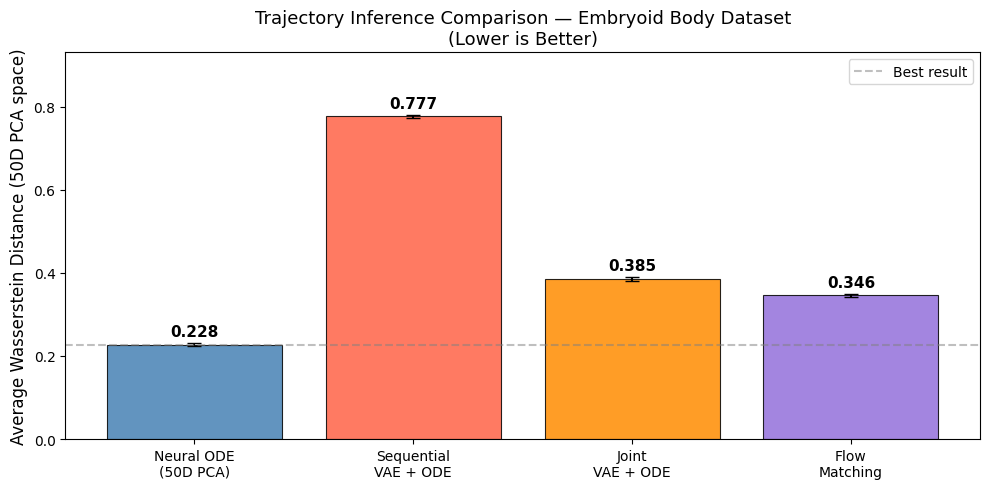


Final Results:
--------------------------------------------------
  Neural ODE (50D PCA)          : 0.2275 ± 0.0037
  Sequential VAE + ODE          : 0.7770 ± 0.0036
  Joint VAE + ODE               : 0.3854 ± 0.0044
  Flow Matching                 : 0.3457 ± 0.0036


In [8]:
methods = [
    'Neural ODE\n(50D PCA)',
    'Sequential\nVAE + ODE',
    'Joint\nVAE + ODE',
    'Flow\nMatching'
]
avgs = [avg_node, avg_vae, avg_joint, avg_fm]
stds = [std_node, std_vae, std_joint, std_fm]
colors = ['steelblue', 'tomato', 'darkorange', 'mediumpurple']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(methods, avgs, yerr=stds, capsize=5,
              color=colors, alpha=0.85, edgecolor='black', linewidth=0.8)

# annotate bars
for bar, avg, std in zip(bars, avgs, stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.01,
            f'{avg:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Average Wasserstein Distance (50D PCA space)', fontsize=12)
ax.set_title('Trajectory Inference Comparison — Embryoid Body Dataset\n'
             '(Lower is Better)', fontsize=13)
ax.set_ylim(0, max(avgs) + max(stds) + 0.15)
ax.axhline(y=min(avgs), color='gray', linestyle='--', alpha=0.5, label='Best result')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../figures/06_final_comparison.png', dpi=150)
plt.show()

print("\nFinal Results:")
print("-" * 50)
for m, a, s in zip(methods, avgs, stds):
    print(f"  {m.replace(chr(10), ' '):30s}: {a:.4f} ± {s:.4f}")

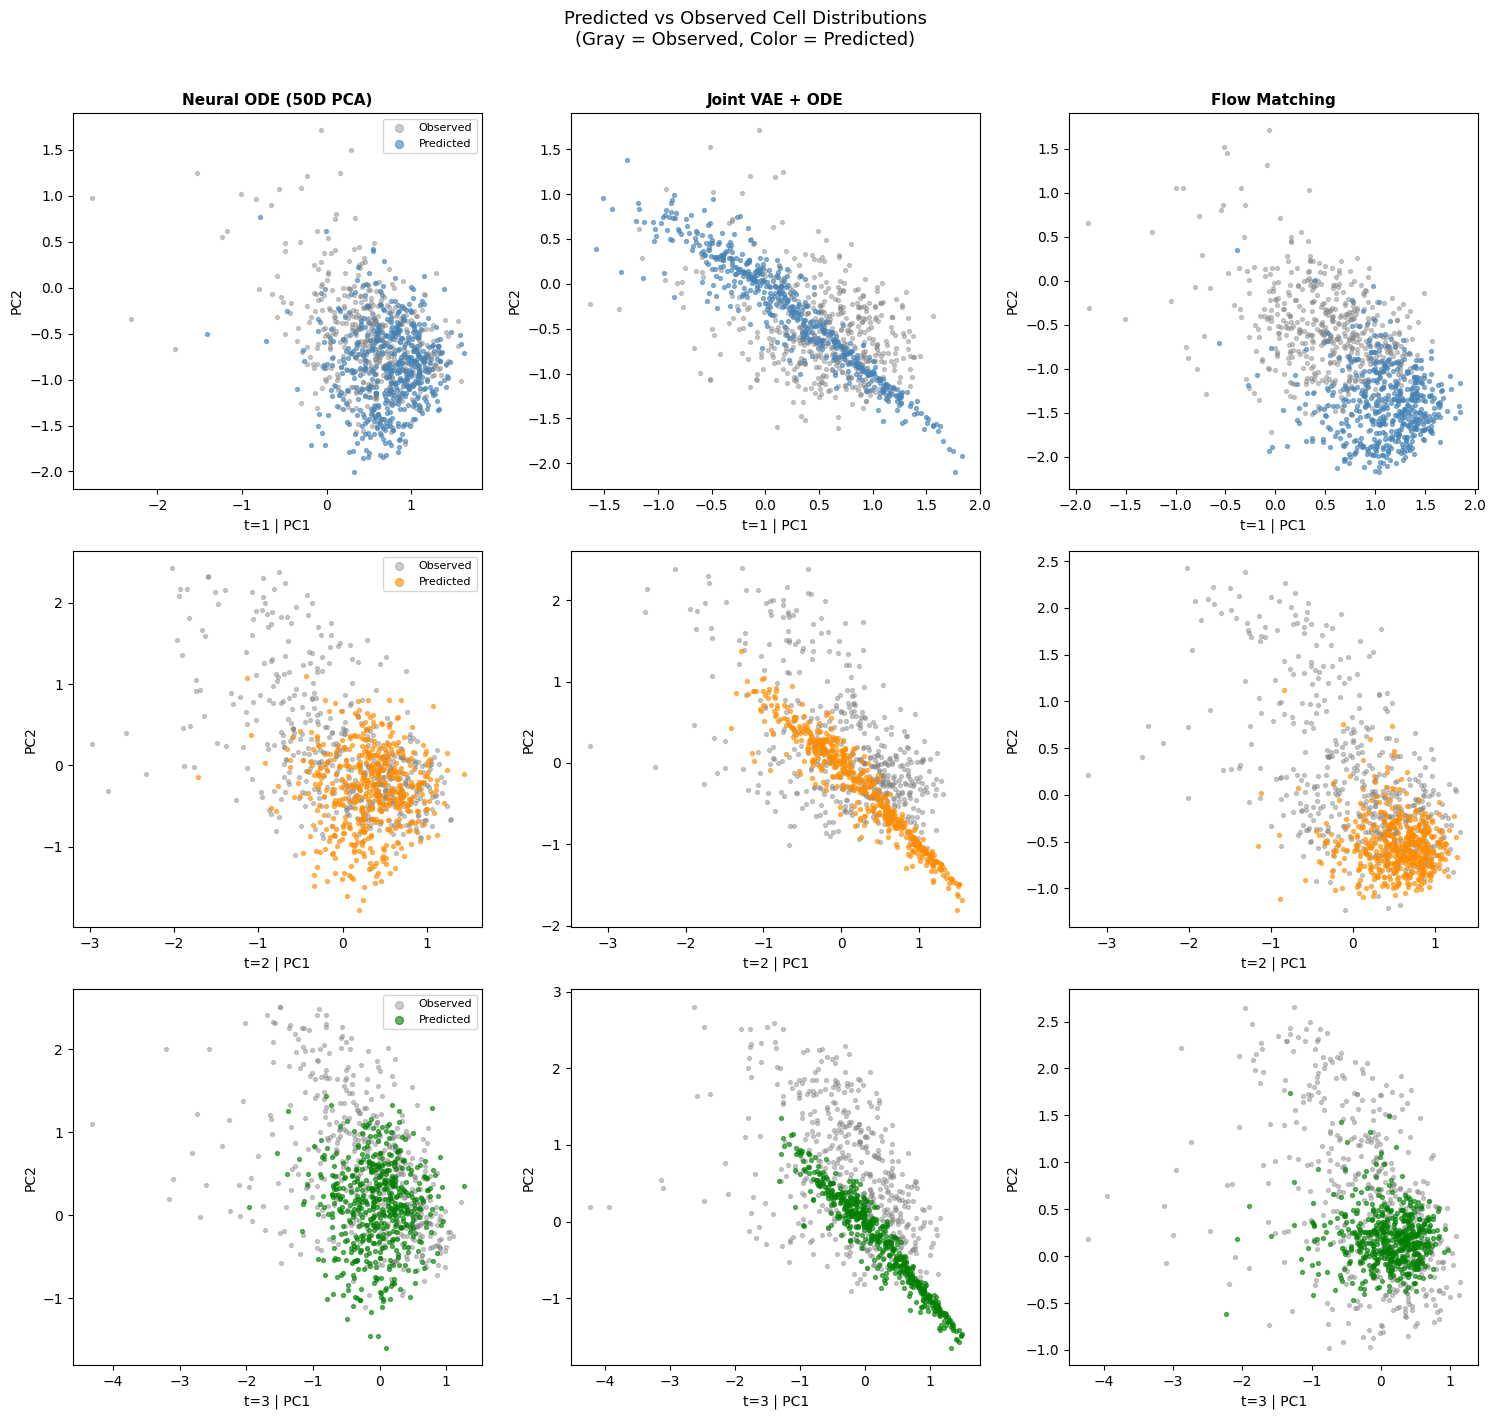

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(15, 14))
method_names = ['Neural ODE (50D PCA)', 'Joint VAE + ODE', 'Flow Matching']
method_preds = [preds_node, preds_joint, preds_fm]
time_labels  = [1, 2, 3]
colors_t     = ['steelblue', 'darkorange', 'green']

for row, t in enumerate(time_labels):
    for col, (name, preds) in enumerate(zip(method_names, method_preds)):
        ax = axes[row, col]
        
        if t in preds:
            pred = preds[t]
        else:
            ax.set_visible(False)
            continue
        
        obs = obs_by_t_pca[t]
        idx_obs = np.random.choice(len(obs), size=min(500, len(pred)), replace=False)
        
        ax.scatter(obs[idx_obs, 0], obs[idx_obs, 1],
                  alpha=0.4, s=8, color='gray', label='Observed')
        ax.scatter(pred[:500, 0], pred[:500, 1],
                  alpha=0.6, s=8, color=colors_t[row], label='Predicted')
        
        if row == 0:
            ax.set_title(name, fontsize=11, fontweight='bold')
        ax.set_xlabel(f't={t} | PC1')
        ax.set_ylabel('PC2')
        if col == 0:
            ax.legend(markerscale=2, fontsize=8)

plt.suptitle('Predicted vs Observed Cell Distributions\n(Gray = Observed, Color = Predicted)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../figures/06_predicted_vs_observed.png', dpi=150, bbox_inches='tight')
plt.show()